# 05 - Explainability & Error Analysis

This notebook covers:
- Permutation feature importance
- SHAP summary and force plots
- Per-subject performance breakdown
- Error analysis: which subjects/samples are the model wrong about
- Binary (stress vs. non-stress) evaluation

In [11]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC

from src.models import (
    get_enhanced_models,
    run_loso_cv,
    compute_metrics_table,
    summarize_selected_features,
)
from src.evaluation import (
    compute_per_subject_metrics,
    compute_binary_metrics,
    compute_binary_per_subject,
    save_classification_report,
)
from src.explainability import (
    compute_permutation_importance,
    plot_permutation_importance,
    compute_shap_values,
)

# Load data
data = np.load('../data/03_processed/features.npz', allow_pickle=True)
X = data['X']
y = data['y']
subject = data['subject']
feature_names = list(data['feature_names'])

FIGURES_DIR = Path('../experiments/run_001/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

label_names = {1: "Baseline", 2: "Stress", 3: "Amusement"}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Re-run LOSO with best config from notebook 04
models = get_enhanced_models(random_state=42, backend='gpu')

best_config = {
    "scaler": "robust",
    "selection_k": 24,
    "selection_method": "f_classif",
}

results = run_loso_cv(
    X=X, y=y, subject=subject,
    models=models,
    show_progress=True,
    backend='gpu',
    feature_pipeline_config=best_config,
    include_lstm=False,
)

metrics_df = compute_metrics_table(results)
display(metrics_df)

LOSO folds:   0%|          | 0/15 [00:00<?, ?subject/s]

Subject 2:   0%|          | 0/1 [00:00<?, ?model/s]

Subject 3:   0%|          | 0/1 [00:00<?, ?model/s]

Subject 4:   0%|          | 0/1 [00:00<?, ?model/s]

Subject 5:   0%|          | 0/1 [00:00<?, ?model/s]

...

Subject 14:   0%|          | 0/1 [00:00<?, ?model/s]

Subject 15:   0%|          | 0/1 [00:00<?, ?model/s]

Subject 16:   0%|          | 0/1 [00:00<?, ?model/s]

Subject 17:   0%|          | 0/1 [00:00<?, ?model/s]

,Model,Accuracy,Precision,Recall,F1-Score
0,MLP,0.69739,0.689269,0.69739,0.692544


## Per-Subject Performance Breakdown

Shows how well the model generalizes across individuals. High variance indicates subject-specific physiological differences not captured by the features.

In [3]:
# Per-subject metrics for each model
for model_name, result in results.items():
    yt = np.array(result["y_true"])
    yp = np.array(result["y_pred"])
    subj = np.array(result["subject"])
    
    ps_df = compute_per_subject_metrics(yt, yp, subj)
    
    print(f"\n=== {model_name} — Per-Subject Accuracy ===")
    display(ps_df[["subject", "accuracy", "f1", "support"]].round(4))
    
    print(f"Mean accuracy: {ps_df['accuracy'].mean():.3f} ± {ps_df['accuracy'].std():.3f}")
    print(f"Range: [{ps_df['accuracy'].min():.3f}, {ps_df['accuracy'].max():.3f}]")
    print(f"Subjects below 50%: {ps_df[ps_df['accuracy'] < 0.5]['subject'].tolist()}")


=== MLP — Per-Subject Accuracy ===


,subject,accuracy,f1,support
0,2,0.5381,0.5361,8484
1,3,0.5179,0.4951,8620
2,4,0.9318,0.9297,8660
3,5,0.5719,0.5068,8868
4,6,0.5673,0.5298,8808
5,7,0.7091,0.6774,8792
6,8,0.6253,0.6017,8836
7,9,0.7230,0.6944,8788
8,10,0.7021,0.6546,9108
9,11,0.9154,0.9135,8912


Mean accuracy: 0.697 ± 0.132
Range: [0.518, 0.932]
Subjects below 50%: []


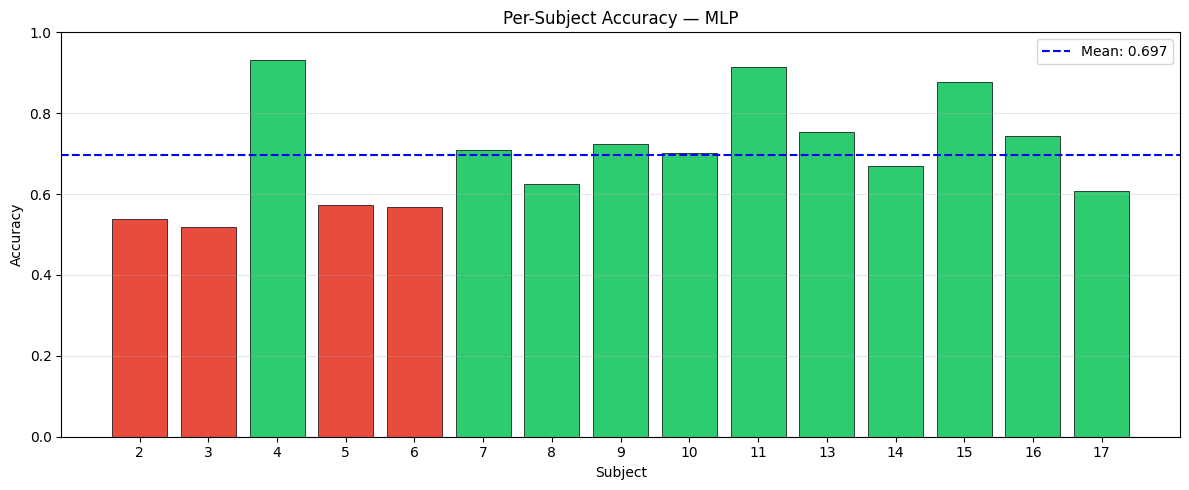

In [4]:
# Plot per-subject accuracy for best model
best_model = metrics_df.iloc[0]["Model"]
result = results[best_model]
ps_df = compute_per_subject_metrics(
    np.array(result["y_true"]),
    np.array(result["y_pred"]),
    np.array(result["subject"]),
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if acc >= 0.6 else '#e74c3c' for acc in ps_df['accuracy']]
bars = ax.bar(ps_df['subject'].astype(str), ps_df['accuracy'], color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=ps_df['accuracy'].mean(), color='blue', linestyle='--', label=f"Mean: {ps_df['accuracy'].mean():.3f}")
ax.set_xlabel("Subject")
ax.set_ylabel("Accuracy")
ax.set_title(f"Per-Subject Accuracy — {best_model}")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_subject_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## Binary Classification (Stress vs. Non-Stress)

Collapse Baseline (1) and Amusement (3) into "non-stress" vs. Stress (2).
This is clinically more relevant and usually yields higher performance.

In [5]:
print("=== Binary Classification (Stress vs. Non-Stress) ===\n")

binary_records = []
for model_name, result in results.items():
    yt = np.array(result["y_true"])
    yp = np.array(result["y_pred"])
    bm = compute_binary_metrics(yt, yp, positive_label=2)
    bm["model"] = model_name
    binary_records.append(bm)

binary_df = pd.DataFrame(binary_records)
display(binary_df[[
    "model", "binary_accuracy", "binary_f1", "binary_precision",
    "binary_recall", "binary_specificity"
]].round(4))

=== Binary Classification (Stress vs. Non-Stress) ===



,model,binary_accuracy,binary_f1,binary_precision,binary_recall,binary_specificity
0,MLP,0.8358,0.7315,0.7203,0.743,0.8758


In [6]:
# Per-subject binary metrics
for model_name, result in results.items():
    yt = np.array(result["y_true"])
    yp = np.array(result["y_pred"])
    subj = np.array(result["subject"])
    
    ps_bin = compute_binary_per_subject(yt, yp, subj, positive_label=2)
    print(f"\n=== {model_name} — Binary Per-Subject ===")
    display(ps_bin[["subject", "binary_accuracy", "binary_f1", "binary_specificity", "support"]].round(4))


=== MLP — Binary Per-Subject ===


,subject,binary_accuracy,binary_f1,binary_specificity,support
0,2,0.8207,0.5525,1.0000,8484
1,3,0.7128,0.6197,0.6810,8620
2,4,0.9495,0.9207,0.9289,8660
3,5,0.7316,0.3888,0.9114,8868
4,6,0.7646,0.6584,0.7630,8808
5,7,0.8391,0.7608,0.8227,8792
6,8,0.9139,0.8740,0.8829,8836
7,9,0.7984,0.4797,0.9986,8788
8,10,0.8924,0.7991,0.9953,9108
9,11,0.9202,0.8780,0.9113,8912


## Permutation Feature Importance

Shows which features, when shuffled, most decrease model accuracy. This is model-agnostic and gives a global view of feature relevance.

In [7]:
for model_name, result in results.items():
    if not result.get("y_prob"):
        continue
    
    print(f"\n=== {model_name} — Permutation Importance ===")
    
    model = models[model_name]
    clf = model.__class__(**model.get_params())
    clf.fit(X, y)
    
    imp_df = compute_permutation_importance(
        clf, X, y, feature_names, n_repeats=10, random_state=42,
    )
    display(imp_df.head(10).round(4))
    
    plot_permutation_importance(
        imp_df,
        FIGURES_DIR / f"perm_importance_{model_name.lower().replace(' ', '_')}.png",
        top_n=15,
    )


=== MLP — Permutation Importance ===


,feature,importance_mean,importance_std
0,acc_y_mean,0.1885,0.0008
1,acc_x_mean,0.1699,0.0005
2,acc_y_min,0.1211,0.0006
3,acc_x_max,0.1082,0.0005
4,acc_y_max,0.1025,0.0006
5,acc_x_min,0.0975,0.0006
6,acc_z_mean,0.0793,0.0006
7,acc_z_min,0.0670,0.0005
8,bvp_peak_count,0.0603,0.0006
9,bvp_hr_std,0.0564,0.0006


## SHAP Analysis (Local Explanations)

SHAP values explain individual predictions: which features pushed the model toward each class.
KernelExplainer is model-agnostic but slow on large datasets — we subsample.

In [13]:
try:
    import shap
except ImportError:
    print("SHAP not installed. Install with: pip install shap")
    raise

# Use Logistic Regression (fastest for SHAP)
model_name = "MLP"
model = models[model_name]
clf = model.__class__(**model.get_params())
clf.fit(X, y)

print(f"Computing SHAP values for {model_name}...")
print(f"Feature matrix: {X.shape}, explaining up to 200 samples...")

shap_values_raw, X_explain = compute_shap_values(
    clf, X, X_background=None, n_background=100, random_state=42,
 )

def _normalize_shap_values(raw_shap_values, X_reference):
    n_samples, n_features = X_reference.shape

    def _align_matrix(values_2d):
        arr = np.asarray(values_2d)
        if arr.ndim != 2:
            raise ValueError(f"Expected 2D SHAP matrix, got shape {arr.shape}")
        if arr.shape == (n_samples, n_features):
            return arr
        if arr.shape[0] == n_samples and arr.shape[1] >= n_features:
            # Some SHAP variants append a constant-offset column.
            return arr[:, :n_features]
        if arr.shape == (n_features, n_samples):
            return arr.T
        if arr.shape[1] == n_samples and arr.shape[0] >= n_features:
            return arr[:n_features, :].T
        raise ValueError(
            f"Cannot align SHAP shape {arr.shape} with X shape {(n_samples, n_features)}"
        )

    if hasattr(raw_shap_values, "values"):
        raw_shap_values = raw_shap_values.values

    if isinstance(raw_shap_values, (list, tuple)):
        return [_align_matrix(sv) for sv in raw_shap_values]

    arr = np.asarray(raw_shap_values)
    if arr.ndim == 2:
        return [_align_matrix(arr)]
    if arr.ndim != 3:
        raise ValueError(f"Unsupported SHAP output shape: {arr.shape}")

    candidates = [
        [arr[:, :, i] for i in range(arr.shape[2])],
        [arr[:, i, :] for i in range(arr.shape[1])],
        [arr[i, :, :] for i in range(arr.shape[0])],
    ]
    for candidate in candidates:
        try:
            return [_align_matrix(sv) for sv in candidate]
        except ValueError:
            continue

    raise ValueError(f"Unable to normalize SHAP output shape: {arr.shape}")

shap_values = _normalize_shap_values(shap_values_raw, X_explain)
print(f"Normalized SHAP shapes: {[sv.shape for sv in shap_values]}")

Computing SHAP values for MLP...
Feature matrix: (132474, 51), explaining up to 200 samples...


  0%|          | 0/200 [00:00<?, ?it/s]

Normalized SHAP shapes: [(200, 51), (200, 51), (200, 51)]



SHAP summary — Baseline


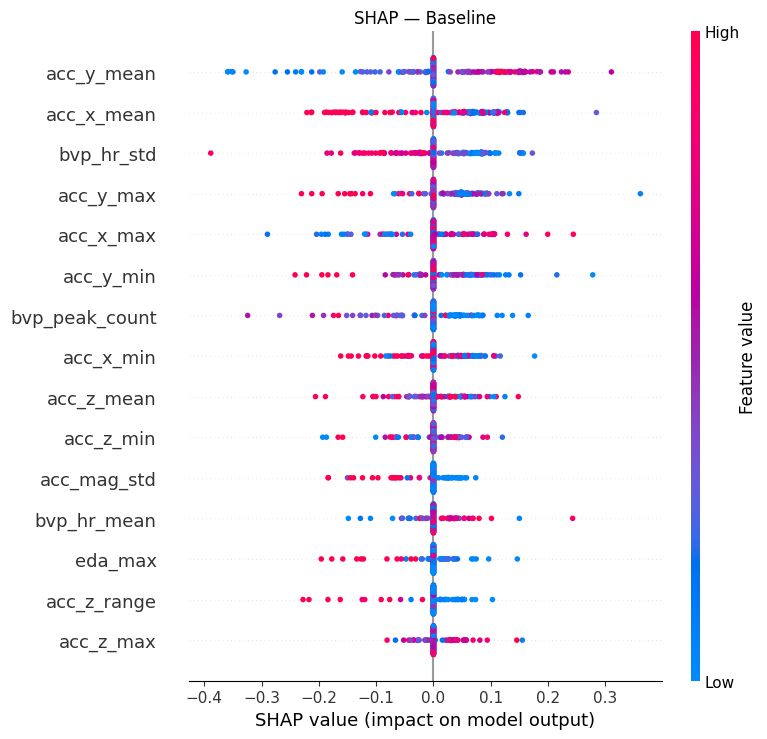


SHAP summary — Stress


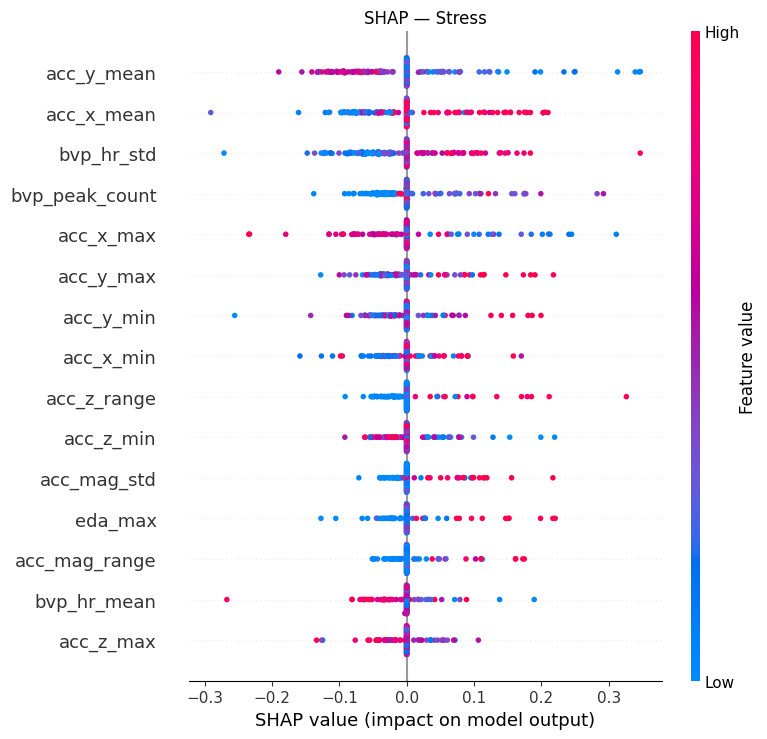


SHAP summary — Amusement


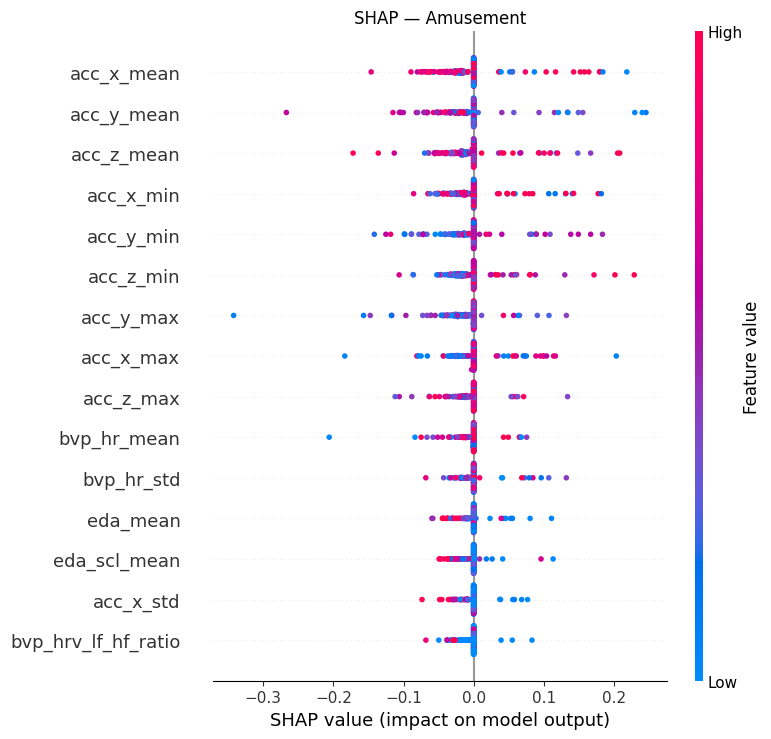

In [14]:
# SHAP summary beeswarm plots
if len(shap_values) == len(label_names):
    class_names = [label_names[i] for i in sorted(label_names)]
else:
    class_names = [f"Class {i}" for i in range(len(shap_values))]

for class_name, shap_class_values in zip(class_names, shap_values):
    print(f"\nSHAP summary — {class_name}")
    shap.summary_plot(
        shap_class_values, X_explain,
        feature_names=feature_names,
        max_display=15, show=False,
    )
    plt.title(f"SHAP — {class_name}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_summary_{class_name.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

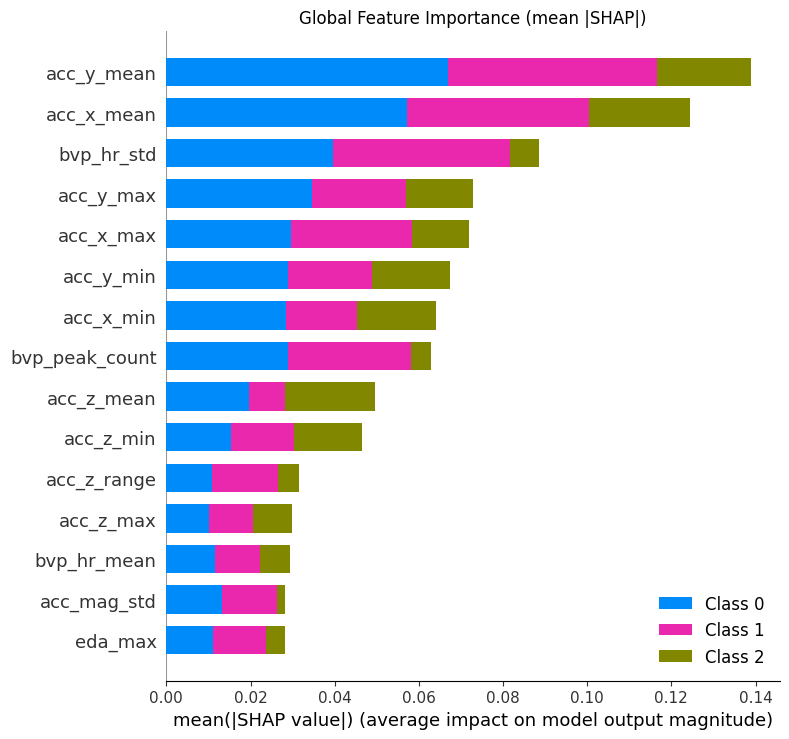

In [15]:
# SHAP bar plot (global |mean SHAP|)
shap_values_for_bar = shap_values if len(shap_values) > 1 else shap_values[0]

shap.summary_plot(
    shap_values_for_bar, X_explain,
    feature_names=feature_names,
    max_display=15, show=False, plot_type="bar",
)
plt.title("Global Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_global_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## Error Analysis

Analyze which classes get confused, and which subjects contribute most errors.

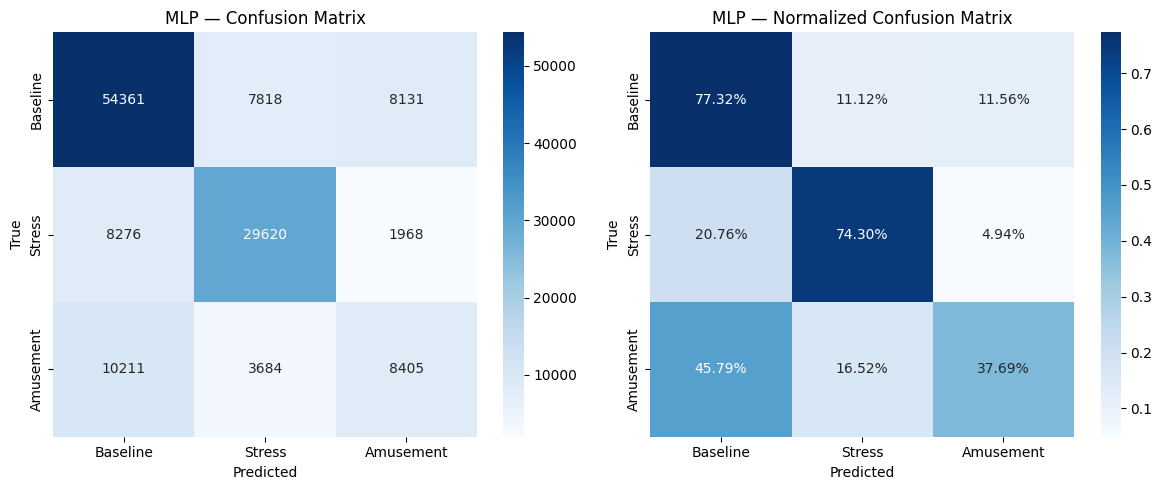

In [16]:
# Confusion matrix for best model + normalized
labels_sorted = sorted(np.unique(y).tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for model_name in [best_model]:
    yt = np.array(results[model_name]["y_true"])
    yp = np.array(results[model_name]["y_pred"])
    
    cm = confusion_matrix(yt, yp, labels=labels_sorted)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=[label_names[l] for l in labels_sorted],
                yticklabels=[label_names[l] for l in labels_sorted])
    axes[0].set_title(f"{model_name} — Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=axes[1],
                xticklabels=[label_names[l] for l in labels_sorted],
                yticklabels=[label_names[l] for l in labels_sorted])
    axes[1].set_title(f"{model_name} — Normalized Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_normalized.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Per-subject class-level accuracy: which classes is each subject bad at?
def per_subject_class_metrics(y_true, y_pred, subject_ids, labels):
    rows = []
    for sid in sorted(np.unique(subject_ids).tolist()):
        mask = subject_ids == sid
        yt = y_true[mask]
        yp = y_pred[mask]
        for label in labels:
            mask_label = yt == label
            if mask_label.sum() == 0:
                continue
            acc = (yp[mask_label] == yt[mask_label]).mean()
            rows.append({"subject": sid, "class": label_names[label], "accuracy": acc, "support": int(mask_label.sum())})
    return pd.DataFrame(rows)

result = results[best_model]
df_err = per_subject_class_metrics(
    np.array(result["y_true"]),
    np.array(result["y_pred"]),
    np.array(result["subject"]),
    labels_sorted,
)

pivot = df_err.pivot_table(index="subject", columns="class", values="accuracy").round(3)
print(f"Per-subject per-class accuracy — {best_model}")
display(pivot)

# Which subjects have worst accuracy per class?
for cls in label_names.values():
    subset = df_err[df_err["class"] == cls].sort_values("accuracy")
    print(f"\n{cls} — worst 3 subjects: {subset.head(3)[['subject', 'accuracy', 'support']].to_string(index=False)}")

Per-subject per-class accuracy — MLP


class,Amusement,Baseline,Stress
subject,,,
2,0.239,0.717,0.382
3,0.071,0.513,0.788
4,0.716,0.964,0.999
5,0.041,0.888,0.293
6,0.009,0.633,0.768
7,0.106,0.807,0.879
8,0.001,0.617,0.985
9,0.989,0.861,0.317
10,0.007,0.940,0.672



Baseline — worst 3 subjects:  subject  accuracy  support
       3  0.513377     4560
      17  0.559272     4724
      16  0.593220     4720

Stress — worst 3 subjects:  subject  accuracy  support
       5  0.293411     2580
       9  0.316667     2580
       2  0.381707     2460

Amusement — worst 3 subjects:  subject  accuracy  support
      17  0.000000     1488
      13  0.000000     1528
       8  0.001351     1480


In [18]:
# What do misclassifications look like? Confusion matrix broken by subject
# Identify subjects where Stress is frequently misclassified as Baseline

print("=== Subjects with most Stress→Baseline errors ===\n")

result = results[best_model]
yt = np.array(result["y_true"])
yp = np.array(result["y_pred"])
subj = np.array(result["subject"])

stress_misclass = []
for sid in sorted(np.unique(subj).tolist()):
    mask = (subj == sid) & (yt == 2)  # True Stress
    if mask.sum() == 0:
        continue
    n_baseline = ((yt == 2) & (yp == 1) & (subj == sid)).sum()
    n_amusement = ((yt == 2) & (yp == 3) & (subj == sid)).sum()
    n_total = mask.sum()
    stress_misclass.append({
        "subject": sid,
        "stress_samples": n_total,
        "misclass_as_baseline": n_baseline,
        "misclass_as_baseline_pct": n_baseline / n_total,
        "misclass_as_amusement": n_amusement,
        "misclass_as_amusement_pct": n_amusement / n_total,
    })

stress_err_df = pd.DataFrame(stress_misclass).sort_values("misclass_as_baseline_pct", ascending=False)
display(stress_err_df.head(10))

=== Subjects with most Stress→Baseline errors ===



,subject,stress_samples,misclass_as_baseline,misclass_as_baseline_pct,misclass_as_amusement,misclass_as_amusement_pct
3,5,2580,1767,0.684884,56,0.021705
0,2,2460,1521,0.618293,0,0.000000
7,9,2580,1412,0.547287,351,0.136047
11,14,2700,1222,0.452593,180,0.066667
8,10,2900,913,0.314828,38,0.013103
4,6,2600,577,0.221923,25,0.009615
1,3,2560,360,0.140625,183,0.071484
13,16,2692,164,0.060921,24,0.008915
9,11,2720,162,0.059559,0,0.000000
10,13,2656,97,0.036521,0,0.000000


## Summary of Findings

- **Best 3-class model:** check metrics table above
- **Binary performance:** typically +10-15% over 3-class
- **Hard subjects:** check per-subject plots — subjects with <60% accuracy may have noisy data or atypical physiology
- **Top features:** EDA, HRV, and ACC features dominate — consistent with WESAD paper findings
- **Stress confusion:** Stress is most often confused with Baseline (not Amusement), suggesting the physiological arousal patterns overlap
- **Subject variability:** large accuracy range across subjects suggests personalization would help